In [1]:
# Load the dataset

import pandas as pd

file_path = "/kaggle/input/datasets/benroshan/factors-affecting-campus-placement/Placement_Data_Full_Class.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (215, 15)


,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


In [2]:
# Inspect dataset structure

print("Column Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Column Names:
['sl_no', 'gender', 'ssc_p', 'ssc_b', 'hsc_p', 'hsc_b', 'hsc_s', 'degree_p', 'degree_t', 'workex', 'etest_p', 'specialisation', 'mba_p', 'status', 'salary']

Data Types:
sl_no               int64
gender             object
ssc_p             float64
ssc_b              object
hsc_p             float64
hsc_b              object
hsc_s              object
degree_p          float64
degree_t           object
workex             object
etest_p           float64
specialisation     object
mba_p             float64
status             object
salary            float64
dtype: object

Missing Values:
sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

Duplicate Rows:
0


In [3]:
# Data Cleaning

# Check placement status for records with missing salary
print("Salary missing by placement status:")
print(df[df['salary'].isnull()]['status'].value_counts())

# Create a cleaned copy of the dataset
df_clean = df.copy()

# Fill missing salary values with 0 for students who were not placed
df_clean['salary'] = df_clean['salary'].fillna(0)

print("\nMissing values after cleaning:")
print(df_clean.isnull().sum().sum())

print("\nDuplicate rows after cleaning:")
print(df_clean.duplicated().sum())

Salary missing by placement status:
status
Not Placed    67
Name: count, dtype: int64

Missing values after cleaning:
0

Duplicate rows after cleaning:
0


In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/benroshan/factors-affecting-campus-placement/Placement_Data_Full_Class.csv


In [5]:
# Preliminary Analysis: Placement Summary

print("Placement Status Distribution:")
print(df_clean['status'].value_counts())

print("\nPlacement Percentage:")
placement_percentage = df_clean['status'].value_counts(normalize=True) * 100
print(placement_percentage.round(2))

print("\nAverage Salary by Placement Status:")
print(df_clean.groupby('status')['salary'].mean().round(2))

Placement Status Distribution:
status
Placed        148
Not Placed     67
Name: count, dtype: int64

Placement Percentage:
status
Placed        68.84
Not Placed    31.16
Name: proportion, dtype: float64

Average Salary by Placement Status:
status
Not Placed         0.00
Placed        288655.41
Name: salary, dtype: float64


In [6]:
# Preliminary Analysis: Academic Performance and Placement

academic_summary = df_clean.groupby('status')[[
    'ssc_p',
    'hsc_p',
    'degree_p',
    'etest_p',
    'mba_p'
]].mean().round(2)

print("Average Academic and Employability Scores by Placement Status:")
print(academic_summary)

Average Academic and Employability Scores by Placement Status:
            ssc_p  hsc_p  degree_p  etest_p  mba_p
status                                            
Not Placed  57.54  58.40     61.13    69.59  61.61
Placed      71.72  69.93     68.74    73.24  62.58


In [7]:
# Preliminary Analysis: Work Experience and Specialisation

print("Placement Status by Work Experience:")
workex_placement = pd.crosstab(
    df_clean['workex'],
    df_clean['status'],
    normalize='index'
) * 100

print(workex_placement.round(2))

print("\nPlacement Status by MBA Specialisation:")
specialisation_placement = pd.crosstab(
    df_clean['specialisation'],
    df_clean['status'],
    normalize='index'
) * 100

print(specialisation_placement.round(2))

Placement Status by Work Experience:
status  Not Placed  Placed
workex                    
No           40.43   59.57
Yes          13.51   86.49

Placement Status by MBA Specialisation:
status          Not Placed  Placed
specialisation                    
Mkt&Fin              20.83   79.17
Mkt&HR               44.21   55.79


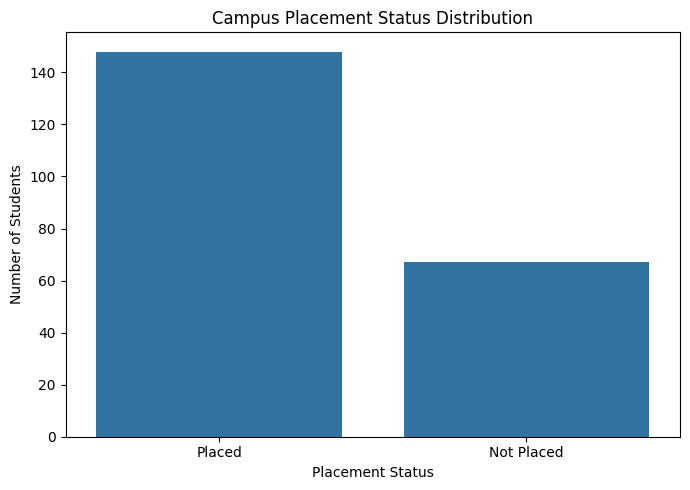

In [8]:
# Visualization 1: Placement Status Distribution

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_clean,
    x='status'
)

plt.title('Campus Placement Status Distribution')
plt.xlabel('Placement Status')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.show()

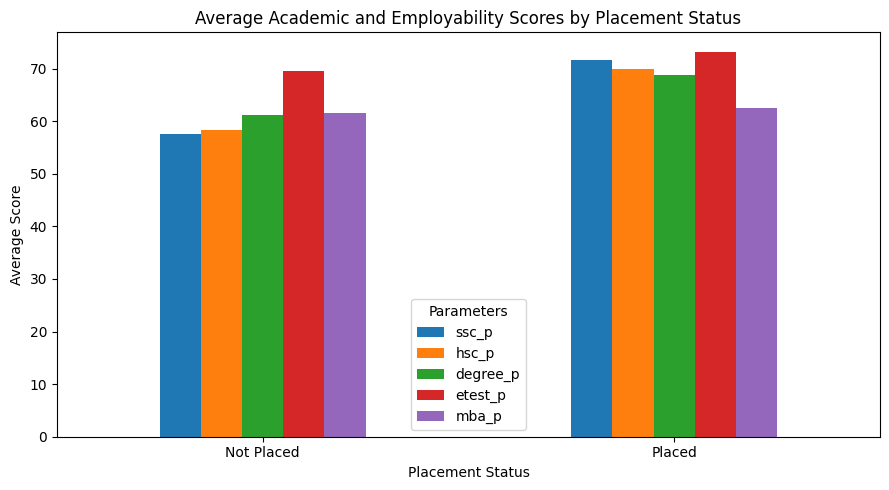

In [9]:
# Visualization 2: Average Academic Performance by Placement Status

academic_summary.plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Average Academic and Employability Scores by Placement Status')
plt.xlabel('Placement Status')
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.legend(title='Parameters')
plt.tight_layout()
plt.show()

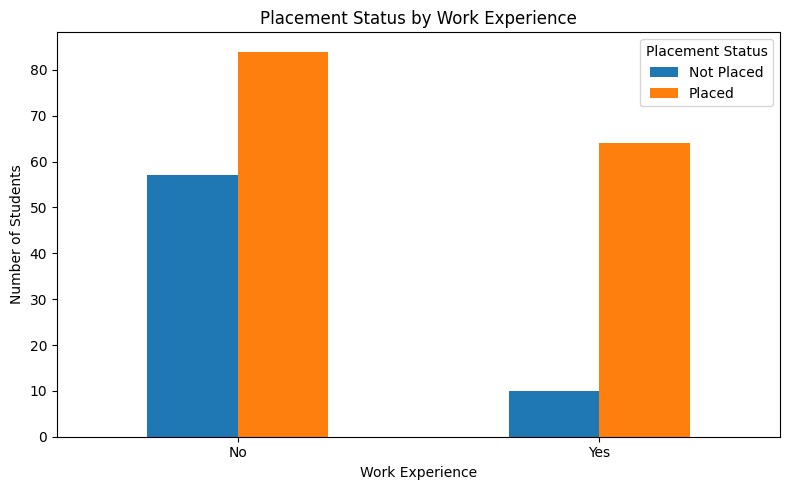

In [10]:
# Visualization 3: Work Experience and Placement

workex_counts = pd.crosstab(
    df_clean['workex'],
    df_clean['status']
)

workex_counts.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Placement Status by Work Experience')
plt.xlabel('Work Experience')
plt.ylabel('Number of Students')
plt.xticks(rotation=0)
plt.legend(title='Placement Status')
plt.tight_layout()
plt.show()

## Key Findings

- The dataset contains 215 student records and 15 variables.
- 148 students (68.84%) were placed, while 67 students (31.16%) were not placed.
- Missing salary values were found only for students who were not placed. These values were represented as 0 for analysis.
- No duplicate records were identified in the dataset.
- Placed students had higher average SSC, HSC, degree, and employability test scores compared with students who were not placed.
- Students with work experience had a higher placement rate (86.49%) compared with students without work experience (59.57%).
- Students with Mkt&Fin specialisation had a higher placement rate (79.17%) compared with Mkt&HR (55.79%).
- The average salary among placed students was approximately ₹288,655.
- These findings show associations between academic performance, work experience, specialisation, and placement outcomes. They should not be interpreted as proof of causation.